In [1]:
import jax
import jax.numpy as jnp
import pennylane as qml
from flax import nnx
from functools import partial
import numpy as np
from QNN_jax import initialize_parameters
import jax
jax.config.update("jax_enable_x64", True)
# -------------------------- 第一步：改造量子电路，原生支持Batch输入 --------------------------
def quantum_neural_network(x, params, n_qubits, n_layers):
    """
    兼容Batch的量子电路核心逻辑：
    - x: 输入张量，形状为 (batch_size, n_qubits)（Batch维度在前）
    - params: 量子电路参数，形状为 (n_layers, 2 * n_qubits)
    - 所有量子门操作自动沿Batch维度向量化，无需手动循环
    """
    # 1. 强制将输入转为JAX张量（兼容np.array/其他格式），并确保是二维（batch, n_qubits）
    x = jnp.atleast_2d(x)
    # 校验特征维度（Batch维度不校验，由NNX自动兼容）
    if x.shape[-1] != n_qubits:
        raise ValueError(f"输入特征维度需为{n_qubits}，当前为{x.shape[-1]}")
    
    # 2. 数据编码：向量化RX门（自动兼容Batch）
    # qml.RX支持批量角度输入，会自动为每个Batch样本应用对应角度的门
    for i in range(n_qubits):
        qml.RX(x[:, i] * jnp.pi, wires=i)  # x[:, i] 取所有Batch样本的第i个特征
    
    # 3. 变分层：向量化旋转/纠缠门（Batch维度自动兼容）
    for layer in range(n_layers):
        # 纠缠层（CNOT无参数，Batch不影响）
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])
        qml.Barrier(wires=range(n_qubits))
        # 旋转层：参数向量化，自动适配Batch
        for i in range(n_qubits):
            qml.RX(params[layer, 2*i], wires=i)  # RX参数
            qml.RZ(params[layer, 2*i+1], wires=i)  # RZ参数
    # 4. 测量：返回每个量子比特的期望值

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

In [2]:
n_qubits = 4
n_layers = 2
dev = qml.device("default.qubit", wires=n_qubits)
# 封装QNode：interface="jax" 确保兼容JAX/NNX的Batch计算
qnode = qml.QNode(quantum_neural_network, dev, interface="jax")
# 测试单个输入
params = initialize_parameters(n_layers, n_qubits)
result = qnode(x=[1,0,1,0], params=params, n_layers=n_layers, n_qubits=n_qubits)
print("单个输入结果:", result)
result

单个输入结果: [Array([0.21062209], dtype=float64), Array([0.09039875], dtype=float64), Array([-0.27025594], dtype=float64), Array([-0.19796214], dtype=float64)]


[Array([0.21062209], dtype=float64),
 Array([0.09039875], dtype=float64),
 Array([-0.27025594], dtype=float64),
 Array([-0.19796214], dtype=float64)]

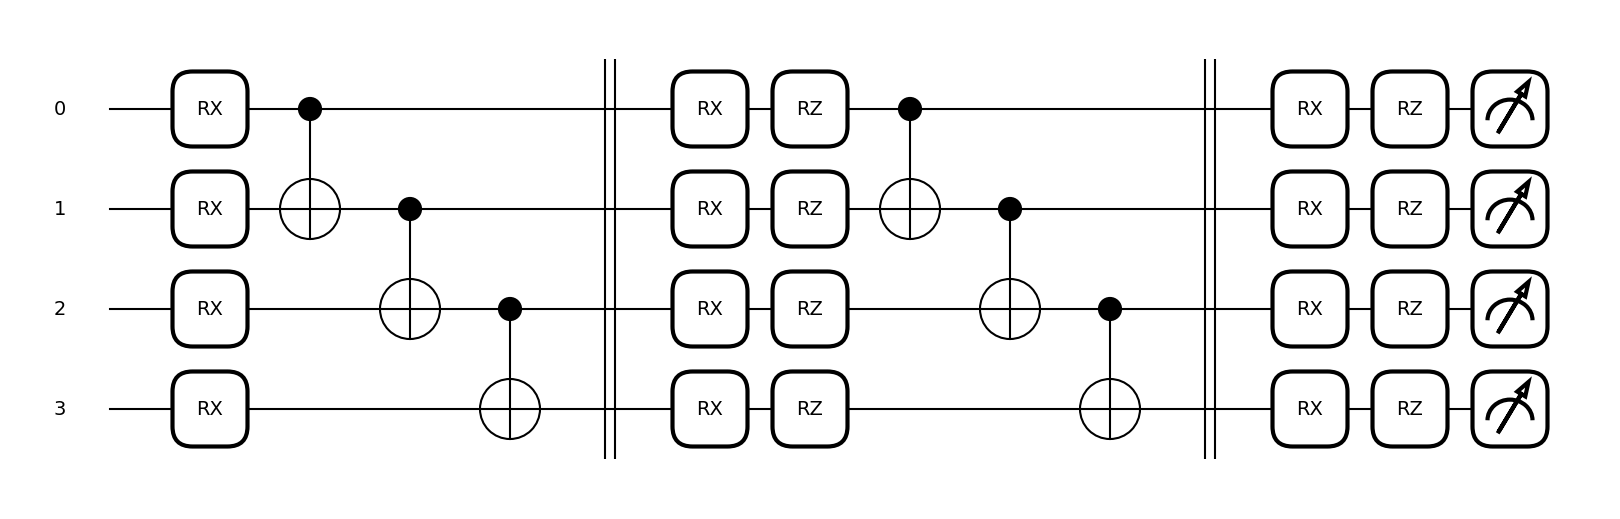

In [3]:
import matplotlib.pyplot as plt
qml.drawer.use_style("black_white")
fig, ax = qml.draw_mpl(qnode)(x=[1,0,1,0],params=initialize_parameters(2,4),n_layers=2,n_qubits=4)
plt.show()

尝试把 QNN jax化

In [4]:
def qnn_circuit(n_qubits:int,n_layers:int):
    dev = qml.device('default.qubit',wires=n_qubits)
    pqc_node = qml.QNode(func=quantum_neural_network,device=dev,interface='jax')
    qnn_node_circuit = partial(pqc_node,n_qubits=n_qubits,n_layers=n_layers)
    return qnn_node_circuit

In [5]:
rngs = nnx.Rngs(params=0)
key = rngs.params()
qnn_func = qnn_circuit(n_qubits=4,n_layers=2)
qnn_func(params=nnx.Param(jax.random.normal(key, (2, 4))),x=[[1,0,1,0]])

[Array([0.3830531], dtype=float64),
 Array([-0.28055583], dtype=float64),
 Array([0.21015436], dtype=float64),
 Array([-0.17590582], dtype=float64)]

In [6]:
linear_layer= nnx.Linear(in_features=4, out_features=4,use_bias=False,rngs=rngs)

In [7]:
y = qnn_func(params=nnx.Param(initialize_parameters(2,4)),x=[1,0,1,0])
y = jnp.array(y)
y

Array([[-0.94512592],
       [ 0.27064636],
       [-0.04444953],
       [-0.11745069]], dtype=float64)

In [8]:
y = qnn_func(params=nnx.Param(initialize_parameters(2,4)), x=[[1,0,1,0]])
y = jnp.array(y)
x = linear_layer(y.reshape(1, 4))
x = nnx.relu(x)
x

Array([[1.48429576, 0.66259167, 0.2952126 , 0.        ]], dtype=float64)

In [9]:
qnn_func(params=nnx.Param(initialize_parameters(2,4)),x=[[1,0,1,0]])


[Array([0.16055171], dtype=float64),
 Array([-0.1898552], dtype=float64),
 Array([-0.05393847], dtype=float64),
 Array([0.05212048], dtype=float64)]

In [10]:
q_fun = qnn_circuit(n_qubits=4,n_layers=2)
qnn_func(x=[[1,0,1,0]],params=nnx.Param(jax.random.normal(key,(2,4),dtype=jnp.float32)))

[Array([-0.09625135], dtype=float64),
 Array([0.37468903], dtype=float64),
 Array([-0.02295585], dtype=float64),
 Array([-0.01601768], dtype=float64)]

In [11]:
from flax import nnx
from functools import partial
class QNNLinear(nnx.Module):
    def __init__(self, rngs: nnx.Rngs,n_qubits:int,n_layer:int):
        self.rngs = rngs
        # 不存储PRNGKey，直接使用rngs.params()初始化参数
        self.n_qubits,self.n_layer = n_qubits,n_layer
        self.qnn_params = nnx.Param(jax.random.normal(rngs.params(), (self.n_layer, 2*self.n_qubits), dtype=jnp.float32))
        self.qnn_layer = partial(qnn_circuit, n_qubits=self.n_qubits, n_layers=self.n_layer)()
        self.Linear = nnx.Linear(in_features=self.n_qubits,out_features=self.n_qubits,use_bias=False,rngs=self.rngs, dtype=jnp.float32)
        
    
    def __call__(self, s:np.array):
        # 确保输入是JAX数组
        s = jnp.array(s, dtype=jnp.float32)
        # 获取QNN输出
        qnn_output = self.qnn_layer(x=s,params=self.qnn_params) #dtype=float32
        print(qnn_output)
        # 将QNN输出转换为float32类型
        qnn_output = jnp.array(qnn_output, dtype=jnp.float32).reshape(-1,self.n_qubits)
        print(qnn_output.dtype)
        y = self.Linear(qnn_output)
        y = nnx.relu(y)
        return jnp.sum(y, axis=-1)
        

In [12]:
model = QNNLinear(n_qubits=4,n_layer=2,rngs=nnx.Rngs(params=0))

In [13]:
model(s=[[1,0,1,0],[0,1,0,1]])

[Array([-0.27599634,  0.27599634], dtype=float64), Array([ 0.16743895, -0.05147613], dtype=float64), Array([0.23240463, 0.23240462], dtype=float64), Array([-0.11858567, -0.11858562], dtype=float64)]
float32


Array([0.5608727, 0.       ], dtype=float32)

接下来在$H_2$分子的VMC中尝试使用这个经典-量子混合模型作为 Ansatz

In [14]:
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
from pyscf import gto, scf, fci
import netket.experimental as nkx

# 设置H2分子的几何构型
bond_length = 0.74  # H2平衡键长（埃）
geometry = [
    ('H', (0., 0., 0.)),
    ('H', (bond_length, 0., 0.)),
]

# 创建分子对象，使用STO-3G基组
mol = gto.M(atom=geometry, basis='STO-3G')

# 进行Hartree-Fock计算
mf = scf.RHF(mol).run(verbose=0)
E_hf = mf.e_tot
print(f"Hartree-Fock能量: {E_hf:.8f} Ha")

# 进行FCI计算作为参考
cisolver = fci.FCI(mf)
E_fci, fcivec = cisolver.kernel()
print(f"FCI能量: {E_fci:.8f} Ha")

# 使用NetKet创建哈密顿量
ha = nkx.operator.from_pyscf_molecule(mol)

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hartree-Fock能量: -1.11675931 Ha
FCI能量: -1.13728383 Ha


In [15]:
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=2,  # 总空间轨道数
    s = 1/2,
    n_fermions_per_spin=(1, 1)  # 每种自旋的电子数
)

# 创建采样器 - 使用费米子跳跃采样器
# 对于分子系统，我们使用完整的轨道图（完全连接）
cluster = [(0,1),(2,3)]
#

# g = nk.graph.Graph(edges=[(0,2),(1,3),(2,0),(3,1)])
g = nk.graph.Graph(edges=[(0,1),(2,3)])
# g = nk.graph.Graph(edges=cluster)
sampler = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, spin_symmetric=True, sweep_size=64
)

In [16]:
from flax import nnx
from functools import partial
import jax

model = QNNLinear(rngs=nnx.Rngs(2),n_qubits=4, n_layer=2)


In [17]:
model(s=[1,0,1,0])

[Array([-0.11303707], dtype=float64), Array([0.07283342], dtype=float64), Array([0.18604357], dtype=float64), Array([0.21916282], dtype=float64)]
float32


Array([0.], dtype=float32)

In [18]:
vstate = nk.vqs.MCState(sampler, model, n_samples=1008)

[Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>]
float32


In [19]:
# 设置优化器
opt = nk.optimizer.Sgd(learning_rate=0.05)
sr = nk.optimizer.SR(diag_shift=0.01)

# 创建VMC驱动器
gs = nk.driver.VMC(ha, opt, variational_state=vstate, preconditioner=sr)

# 运行优化
exp_name = "h2_molecule_qnn"

In [20]:
gs.run(300, out=exp_name)

  0%|          | 0/300 [00:00<?, ?it/s]

[Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>]
float32
[Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>]
float32
[Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>, Traced<float64[16]>with<DynamicJaxprTrace>]
float32
[Traced<float64[1008]>with<DynamicJaxprTrace>, Traced<float64[1008]>with<DynamicJaxprTrace>, Traced<float64[1008]>with<DynamicJaxprTrace>, Traced<float64[1008]>with<DynamicJaxprTrace>]
float32
[Traced<float64[2016]>with<DynamicJaxprTrace>, Traced<float64[2016]>with<DynamicJaxprTrace>, Traced<float64[2016]>with<DynamicJaxprTrace>, Traced<float64[2016]>with<DynamicJaxprTrace>]
float32
[Traced<float64[1008]>with<DynamicJaxprTrace>, Traced<float

  0%|          | 0/300 [00:07<?, ?it/s, Energy=-0.169 ± 0.019 [σ²=0.376, R̂=1.0122]]


TypeError: JAX array with PRNGKey dtype cannot be converted to a NumPy array. Use jax.random.key_data(arr) if you wish to extract the underlying integer array.